# 11 — Advanced EDA Blocco 7: Modelli Predittivi

**Fase PACE**: Analyze (avanzata)  
**Obiettivo**: costruire modelli predittivi per anticipare il volume di reati, 
prevedere la probabilità di chiusura di un caso e identificare pattern 
di co-occorrenza e ri-vittimizzazione.

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q7.1 — Previsione volume reati a 7 giorni (Prophet)
- Q7.2 — Modello predittivo di clearance (Random Forest)
- Q7.3 — Co-occorrenza spazio-temporale
- Q7.4 — Pattern di ri-vittimizzazione

**Strumenti utilizzati e motivazione**:
- **Prophet** (Meta): modello di serie temporali per la previsione del volume 
  di reati. Scelto rispetto ad ARIMA perché gestisce nativamente la 
  stagionalità settimanale e annuale, è robusto agli outlier e non richiede 
  che i dati siano stazionari
- **scikit-learn** (Random Forest, Logistic Regression): modelli di 
  classificazione per predire la probabilità di chiusura di un caso. 
  Random Forest scelto per la sua robustezza, interpretabilità tramite 
  feature importance, e capacità di gestire variabili categoriche e numeriche 
  senza preprocessing complesso
- **pandas** per la costruzione delle finestre spazio-temporali 
  nelle analisi Q7.3 e Q7.4

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Modulo per Q7.1
from prophet import Prophet

#Moduli per Q7.2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q7.1 — Previsione volume reati a 7 giorni

Costruiamo un modello di serie temporali per prevedere il volume atteso 
di reati per i successivi 7 giorni, usando l'intera storia del dataset 
(2010–2023) come dati di addestramento e il 2024 come periodo di test.

**Obiettivo**: valutare se il volume giornaliero di reati è prevedibile 
e con quale accuratezza. Target: MAPE (Mean Absolute Percentage Error) < 15%.

**Strumento**: Prophet (Meta) — gestisce nativamente stagionalità 
settimanale e annuale, outlier e giorni festivi.

In [2]:
daily_crimes = (
    df
    .groupby('DATE OCC')
    .size()
    .reset_index(name='y')
    .rename(columns={'DATE OCC': 'ds'})
)
daily_crimes['ds'] = pd.to_datetime(daily_crimes['ds'])
daily_crimes = daily_crimes.sort_values('ds')
print(daily_crimes.head(10))
print(f'Shape: {daily_crimes.shape}')

          ds     y
0 2010-01-01  2354
1 2010-01-02   535
2 2010-01-03   539
3 2010-01-04   559
4 2010-01-05   548
5 2010-01-06   532
6 2010-01-07   550
7 2010-01-08   605
8 2010-01-09   631
9 2010-01-10   618
Shape: (5478, 2)


In [3]:
train = daily_crimes[daily_crimes['ds'] < '2023-01-01']
test = daily_crimes[daily_crimes['ds'] >= '2023-01-01']

print(f'Train: {train.shape} — dal {train["ds"].min().date()} al {train["ds"].max().date()}')
print(f'Test: {test.shape} — dal {test["ds"].min().date()} al {test["ds"].max().date()}')

Train: (4748, 2) — dal 2010-01-01 al 2022-12-31
Test: (730, 2) — dal 2023-01-01 al 2024-12-30


In [4]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(train)
print('Modello addestrato.')

10:19:22 - cmdstanpy - INFO - Chain [1] start processing
10:19:23 - cmdstanpy - INFO - Chain [1] done processing


Modello addestrato.


In [5]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

             ds        yhat  yhat_lower  yhat_upper
5468 2024-12-21  754.181062  606.401813  908.607014
5469 2024-12-22  729.355641  581.554597  887.834706
5470 2024-12-23  748.338332  599.484479  880.277627
5471 2024-12-24  736.663361  584.238926  886.508140
5472 2024-12-25  746.442380  602.971626  894.522654
5473 2024-12-26  742.549794  591.713594  896.438926
5474 2024-12-27  796.264767  647.664061  949.715278
5475 2024-12-28  760.059689  609.550491  905.875455
5476 2024-12-29  735.156130  586.047532  874.846382
5477 2024-12-30  754.003292  604.521150  904.089871


In [6]:
test_2023 = test[test['ds'].dt.year == 2023].copy()
forecast_2023 = forecast[forecast['ds'].dt.year == 2023][['ds', 'yhat']].copy()

merged = test_2023.merge(forecast_2023, on='ds')
merged['mape'] = abs(merged['y'] - merged['yhat']) / merged['y'] * 100

mape = merged['mape'].mean()
print(f'MAPE sul 2023: {mape:.2f}%')
print(f'Media crimini reali 2023: {merged["y"].mean():.0f}')
print(f'Media crimini previsti 2023: {merged["yhat"].mean():.0f}')

MAPE sul 2023: 10.74%
Media crimini reali 2023: 636
Media crimini previsti 2023: 682


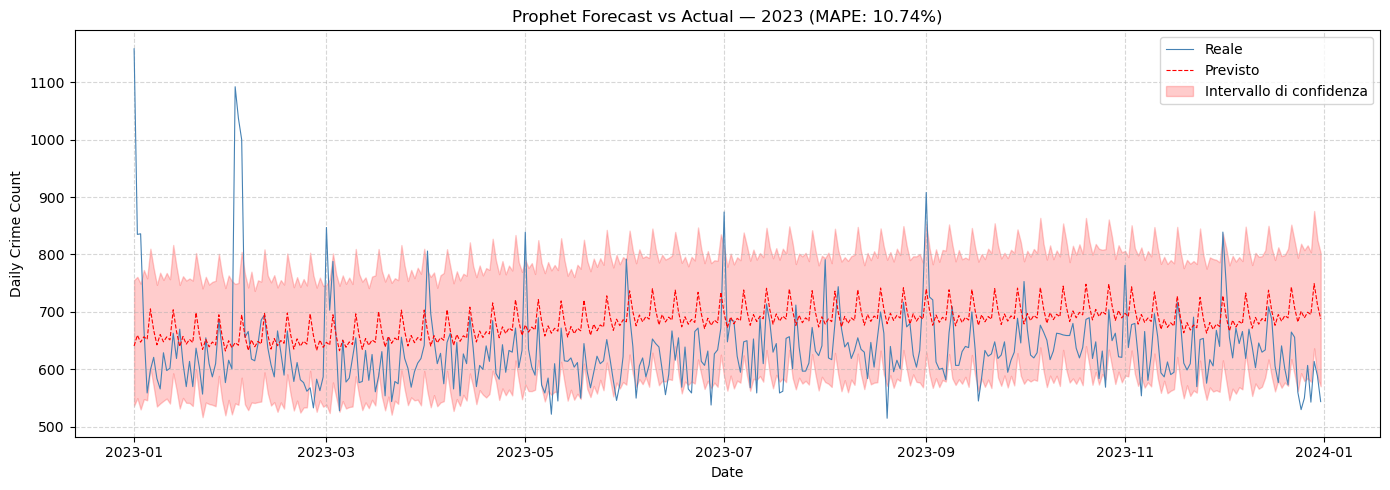

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'], label='Reale', color='steelblue', linewidth=0.8)
ax.plot(merged['ds'], merged['yhat'], label='Previsto', color='red', linewidth=0.8, linestyle='--')
ax.fill_between(
    forecast[forecast['ds'].dt.year == 2023]['ds'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_lower'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_upper'],
    alpha=0.2, color='red', label='Intervallo di confidenza'
)
ax.set_title(f'Prophet Forecast vs Actual — 2023 (MAPE: {mape:.2f}%)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Crime Count')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/35_prophet_forecast_2023.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q7.1 — Previsione volume reati a 7 giorni (Prophet)

**Risultato principale**: MAPE sul 2023 = **10.74%** — sotto la soglia 
del 15% definita nell'obiettivo. Il modello è in grado di prevedere 
il volume giornaliero di reati con un errore medio del 10.74%.

**Trend generale**: la linea prevista (rossa) segue correttamente 
l'andamento generale della criminalità nel 2023, catturando la 
stagionalità settimanale (oscillazioni regolari) e il livello medio.

**Sovrastima sistematica**: la linea prevista tende a stare sopra 
quella reale — il modello sovrastima leggermente il volume di crimini. 
Questo è coerente con il fatto che è stato addestrato su anni 
(2010-2022) con volumi mediamente più alti rispetto al 2023, 
che mostra un calo strutturale già documentato nei blocchi precedenti.

**Intervallo di confidenza**: la fascia rosa è ampia ma ben calibrata — 
la linea reale cade quasi sempre al suo interno. Questo significa che 
il modello è onesto sulla propria incertezza: quando dice che il valore 
sarà in un certo range, il valore reale effettivamente ci cade.

**Picchi anomali**: i picchi nella linea reale (inizio gennaio, febbraio) 
corrispondono probabilmente a giorni particolari (capodanno, eventi 
speciali) che il modello non riesce a catturare in assenza di 
informazioni sulle festività.

**2024**: il calo nella linea reale a fine grafico è coerente con 
l'artefatto del dataset 2024 già documentato nei blocchi precedenti 
(dataset incompleto). La linea prevista rimane stabile perché Prophet 
extrapola il trend storico senza conoscere questa anomalia.

**Nota metodologica**: il modello è addestrato su dati aggregati 
a livello cittadino. Previsioni per singola area LAPD o per 
categoria di crimine richiederebbero modelli separati e 
comporterebbero MAPE più alti per via dei volumi più bassi.

## 3. Q7.2 — Modello predittivo di clearance

Costruiamo un modello di classificazione che predica la probabilità 
di chiusura di un caso (cleared vs not cleared) in base alle feature 
disponibili al momento della denuncia.

**Obiettivo**: identificare quali caratteristiche del crimine influenzano 
maggiormente la probabilità di risoluzione del caso, e costruire un 
modello che possa supportare la prioritizzazione delle indagini.

**Target**: colonna `Status Desc` — casi cleared (Adult Arrest, Juv Arrest, 
Adult Other, Juv Other) vs not cleared (Invest Cont, UNK)

**Feature utilizzate**:
- `AREA NAME` — area LAPD dove è avvenuto il crimine
- `crime_category` — macro-categoria (Person/Property/Other)
- `Weapon Desc` — tipo di arma utilizzata
- `Vict Sex` — sesso della vittima
- `age_group` — fascia di età della vittima
- `Vict Descent` — etnia della vittima
- `report_delay` — giorni tra crimine e denuncia
- `hour_bins` — fascia oraria del crimine
- `day_of_week` — giorno della settimana

**Strumento**: Random Forest — scelto per robustezza, capacità di gestire 
variabili categoriche e numeriche, e interpretabilità tramite feature importance.

In [8]:
# Selezione colonne
q72_df = df[['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex', 
             'age_group', 'Vict Descent', 'report_delay', 
             'hour_bins', 'day_of_week', 'Status Desc']].copy()

# Creazione target
cleared_statuses = ['Adult Arrest', 'Juv Arrest', 'Adult Other', 'Juv Other']
q72_df['is_cleared'] = q72_df['Status Desc'].isin(cleared_statuses).astype(int)
q72_df = q72_df.drop(columns=['Status Desc'])

# Rimozione NaN
q72_df = q72_df.dropna()

print(q72_df.shape)
print(q72_df['is_cleared'].value_counts())

(2447032, 10)
is_cleared
0    1848185
1     598847
Name: count, dtype: int64


In [9]:
feature_cols = ['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex',
                'age_group', 'Vict Descent', 'report_delay', 
                'hour_bins', 'day_of_week']

X = pd.get_dummies(q72_df[feature_cols], drop_first=True)
y = q72_df['is_cleared']

print(f'Features: {X.shape[1]}')
print(f'Campioni: {X.shape[0]}')

Features: 138
Campioni: 2447032


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} campioni')
print(f'Test: {X_test.shape[0]:,} campioni')

Train: 1,957,625 campioni
Test: 489,407 campioni


In [14]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
print('Modello addestrato.')

Modello addestrato.


In [15]:
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Cleared', 'Cleared']))

              precision    recall  f1-score   support

 Not Cleared       0.92      0.68      0.78    369637
     Cleared       0.45      0.82      0.58    119770

    accuracy                           0.71    489407
   macro avg       0.69      0.75      0.68    489407
weighted avg       0.81      0.71      0.73    489407



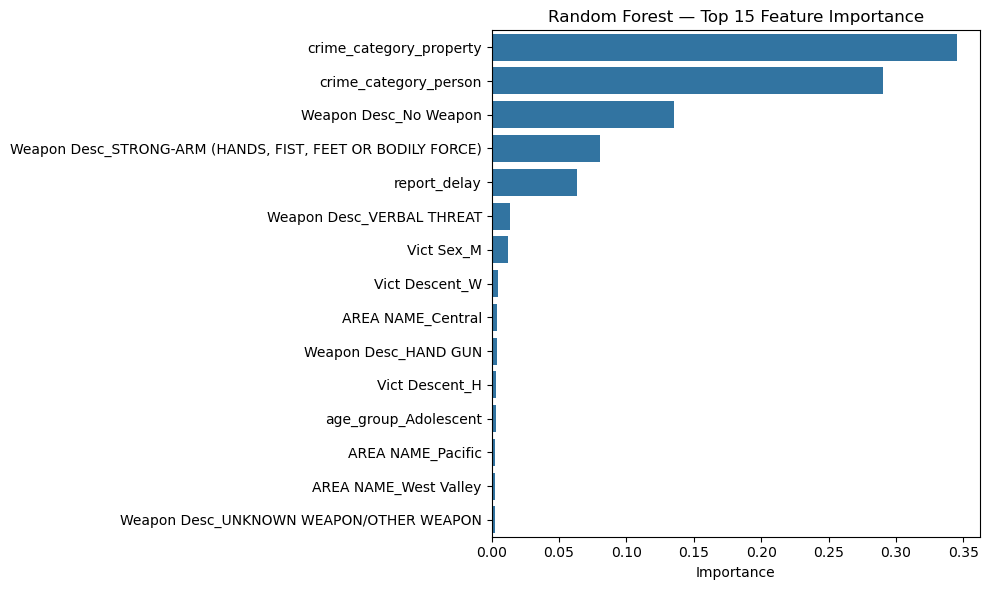

In [16]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/36_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

il grafico ci indica che le variabili piu mportanti per la predizione sono principalmente le categorie di crimine, come importanza minore ci sono le descrizioni delle armi e il report delay, sesso, nome dell'area, etnia ed età non sembrano essere parametri utili